# How do I represent and compare molecules?

> **Pipeline stage:** Foundations  
> **Question this answers:** How do I represent and compare molecules?  
> **Maturity:** Mature  
> **Key caveat:** SMILES is fragile and non-unique — canonicalize. Structural similarity is not functional similarity.

*This is a learning notebook. Read the markdown between cells — the goal is to understand what the tool does and how it hands off to the next stage, not to discover anything.*


Read **docs/background/03_cheminformatics_basics.md** alongside this notebook.

We'll load four molecules that all touch the serotonin system, then *see* how they relate: serotonin (the endogenous ligand) and three classic psychedelics from three different chemotypes.


In [1]:
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, DataStructs
import pandas as pd

# Public reference structures (SMILES). These are reference data, not products.
mols = {
    'serotonin': 'NCCc1c[nH]c2ccc(O)cc12',
    'psilocin (tryptamine)': 'CN(C)CCc1c[nH]c2cccc(O)c12',
    'mescaline (phenethylamine)': 'NCCc1cc(OC)c(OC)c(OC)c1',
    'LSD (ergoline)': 'CCN(CC)C(=O)[C@H]1CN([C@@H]2Cc3c[nH]c4cccc(c34)C2=C1)C',
}
ms = {k: Chem.MolFromSmiles(v) for k, v in mols.items()}
assert all(m is not None for m in ms.values()), 'a SMILES failed to parse'
print('parsed', len(ms), 'molecules')


parsed 4 molecules


### Descriptors — the numbers behind 'drug-likeness'
Note especially molecular weight and logP; they matter for brain penetrance (Primer 7).


In [2]:
rows = []
for name, m in ms.items():
    rows.append({
        'name': name,
        'MW': round(Descriptors.MolWt(m), 1),
        'logP': round(Descriptors.MolLogP(m), 2),
        'HBD': Descriptors.NumHDonors(m),
        'HBA': Descriptors.NumHAcceptors(m),
        'TPSA': round(Descriptors.TPSA(m), 1),
    })
df = pd.DataFrame(rows); df


,name,MW,logP,HBD,HBA,TPSA
0,serotonin,176.2,1.37,3,2,62.0
1,psilocin (tryptamine),204.3,1.98,2,2,39.3
2,mescaline (phenethylamine),211.3,1.21,1,4,53.7
3,LSD (ergoline),323.4,2.91,1,2,39.3


### Similarity — do shared receptor targets mean similar structures?
Compute Morgan fingerprints and a Tanimoto similarity matrix. Watch how *low* some similarities are despite a shared 5-HT2A target — structure ≠ function.


In [3]:
# Morgan (ECFP-like) fingerprints via the modern generator API.
# (The old AllChem.GetMorganFingerprintAsBitVect still works but prints a deprecation warning.)
from rdkit.Chem import rdFingerprintGenerator
import numpy as np

mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
fps = {n: mfpgen.GetFingerprint(m) for n, m in ms.items()}

# Tanimoto similarity = (shared bits) / (total bits set in either). 1.0 = identical bit pattern.
names = list(fps)
M = np.zeros((len(names), len(names)))
for i, a in enumerate(names):
    for j, b in enumerate(names):
        M[i, j] = DataStructs.TanimotoSimilarity(fps[a], fps[b])
pd.DataFrame(M, index=names, columns=[n.split()[0] for n in names]).round(2)


,serotonin,psilocin,mescaline,LSD
serotonin,1.00,0.30,0.21,0.14
psilocin (tryptamine),0.30,1.00,0.10,0.26
mescaline (phenethylamine),0.21,0.10,1.00,0.06
LSD (ergoline),0.14,0.26,0.06,1.00


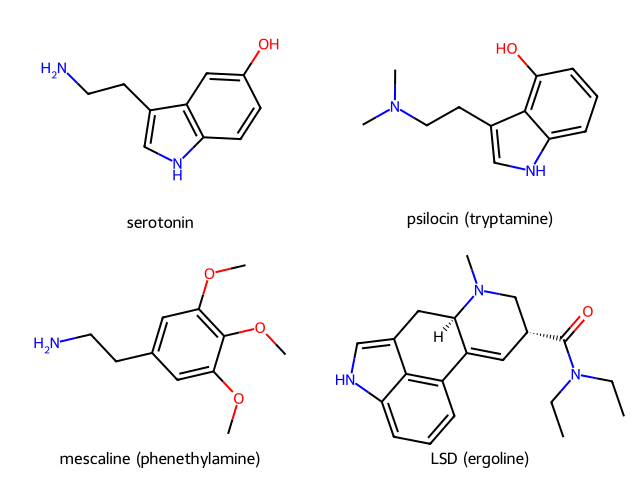

In [4]:
# Draw them so the chemotype differences are visible.
Draw.MolsToGridImage(list(ms.values()), legends=list(ms.keys()), molsPerRow=2, subImgSize=(320,240))


---
## What you should now understand
How to turn SMILES into molecules, compute descriptors, and quantify structural similarity — and the crucial lesson that molecules sharing a receptor target can be structurally quite different (different chemotypes), which foreshadows why character and bias are hard to predict.

## Hands off to
**`02_target_structure.ipynb`** — now we look at the protein these molecules bind.
